In [9]:
import kagglehub, pandas as pd

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(f"{path}/creditcard.csv")

float_cols = df.select_dtypes("float64").columns
df[float_cols] = df[float_cols].astype("float32")   # Done this to optimize memory usage cause of 8GB RAM

df.head()
print(df.shape)
print(f"fraud rate: {df.Class.mean():.4%}")

df["hour"] = (df.Time//3600) % 24
print(df.groupby("hour").Class.mean().sort_values(ascending=False).head())
print(df.groupby("Class").Amount.describe())



(284807, 31)
fraud rate: 0.1727%
hour
2.0    0.017127
4.0    0.010412
3.0    0.004868
5.0    0.003679
7.0    0.003175
Name: Class, dtype: float64
          count        mean         std  min   25%    50%         75%  \
Class                                                                   
0      284315.0   88.291023  250.105103  0.0  5.65  22.00   77.050003   
1         492.0  122.211319  256.683289  0.0  1.00   9.25  105.889999   

                max  
Class                
0      25691.160156  
1       2125.870117  


### 48 Hour vs 24 Hour
So we basically converted the 2 days time perios into hour window of 24 but given that we are correlateing that hpur 1 of day 1 is same as hour 1 of day 2 that needs to be checked cause it might be actually not true or hiding the data by grouping them into one. Below is the plot to check the same. 

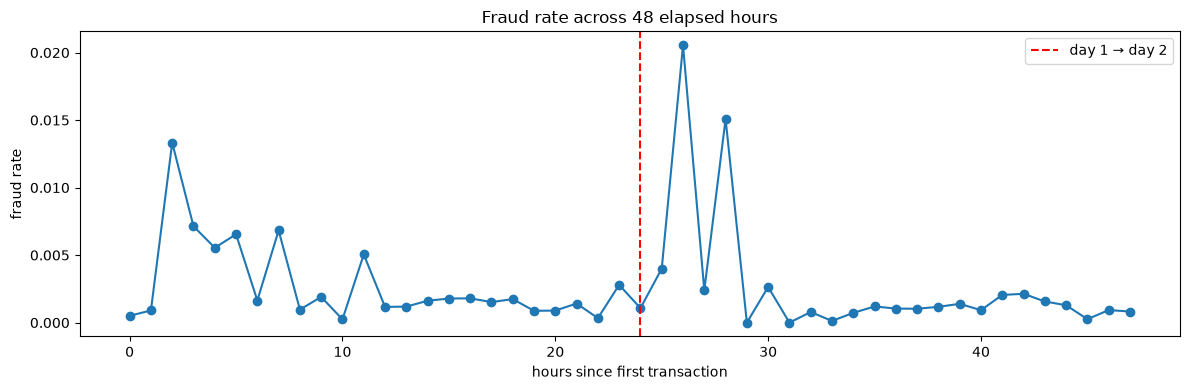

In [11]:
import matplotlib.pyplot as plt

# elapsed hours from the first transaction: 0 to ~47 (no wrap yet)
df["elapsed_hour"] = df.Time // 3600

# fraud rate per elapsed hour = mean of Class within each hour bucket
hourly = df.groupby("elapsed_hour")["Class"].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly.index, hourly.values, marker="o")
ax.axvline(24, color="red", linestyle="--", label="day 1 → day 2")
ax.set_xlabel("hours since first transaction")
ax.set_ylabel("fraud rate")
ax.set_title("Fraud rate across 48 elapsed hours")
ax.legend()
fig.tight_layout()
fig.savefig("reports/figures/00_fraud_by_elapsed_hour.png", dpi=150)
plt.show()

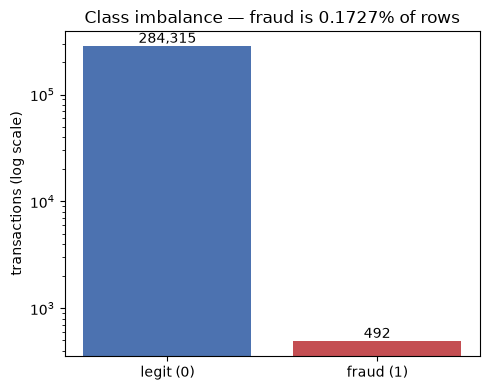

In [14]:
#01 CLass Balance
import matplotlib.pyplot as plt

counts = df.Class.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["legit (0)", "fraud (1)"], counts.values, color=["#4C72B0", "#C44E52"])
ax.set_yscale("log")
ax.set_ylabel("transactions (log scale)")
ax.set_title(f"Class imbalance — fraud is {df.Class.mean():.4%} of rows")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig("reports/figures/01_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

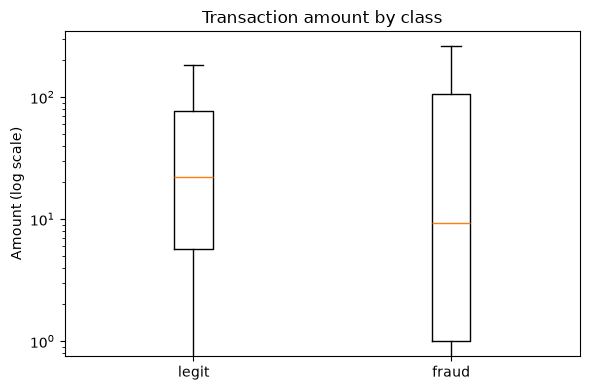

In [15]:
#02 Amount by class
fig, ax = plt.subplots(figsize=(6, 4))
data = [df.loc[df.Class == 0, "Amount"], df.loc[df.Class == 1, "Amount"]]
ax.boxplot(data, tick_labels=["legit", "fraud"], showfliers=False)
ax.set_yscale("log")
ax.set_ylabel("Amount (log scale)")
ax.set_title("Transaction amount by class")
fig.tight_layout()
fig.savefig("reports/figures/02_amount_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

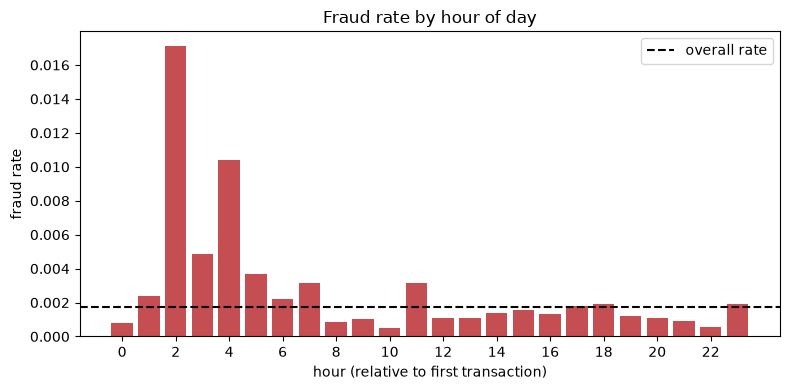

In [17]:
#03 Fraud rate by hour
hourly = df.groupby("hour").Class.mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(hourly.index, hourly.values, color="#C44E52")
ax.axhline(df.Class.mean(), color="black", linestyle="--", label="overall rate")
ax.set_xlabel("hour (relative to first transaction)")
ax.set_ylabel("fraud rate")
ax.set_title("Fraud rate by hour of day")
ax.set_xticks(range(0, 24, 2))
ax.legend()
fig.tight_layout()
fig.savefig("reports/figures/03_fraud_rate_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

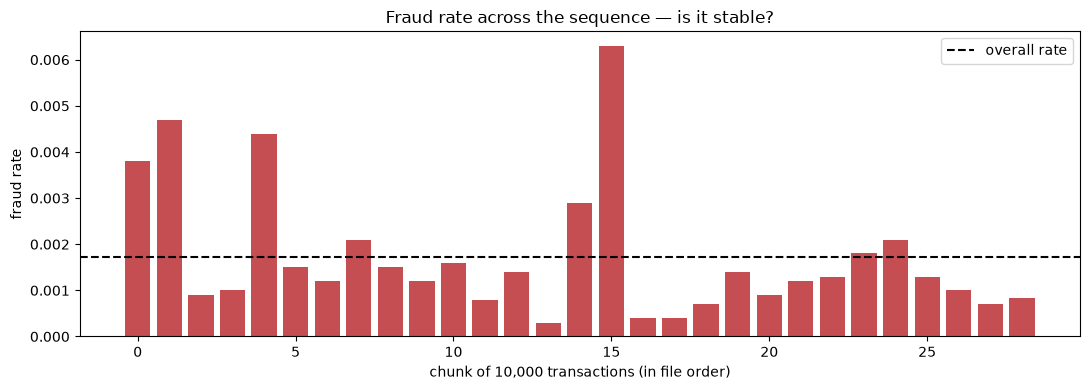

           n  frauds      rate
chunk                         
0      10000      38  0.003800
1      10000      47  0.004700
2      10000       9  0.000900
3      10000      10  0.001000
4      10000      44  0.004400
5      10000      15  0.001500
6      10000      12  0.001200
7      10000      21  0.002100
8      10000      15  0.001500
9      10000      12  0.001200
10     10000      16  0.001600
11     10000       8  0.000800
12     10000      14  0.001400
13     10000       3  0.000300
14     10000      29  0.002900
15     10000      63  0.006300
16     10000       4  0.000400
17     10000       4  0.000400
18     10000       7  0.000700
19     10000      14  0.001400
20     10000       9  0.000900
21     10000      12  0.001200
22     10000      13  0.001300
23     10000      18  0.001800
24     10000      21  0.002100
25     10000      13  0.001300
26     10000      10  0.001000
27     10000       7  0.000700
28      4807       4  0.000832


In [19]:
# Checking fraud by chunks
CHUNK = 10_000
df["chunk"] = df.index // CHUNK

by_chunk = df.groupby("chunk").agg(
    n=("Class", "size"),
    frauds=("Class", "sum"),
    rate=("Class", "mean"),
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(by_chunk.index, by_chunk["rate"], color="#C44E52")
ax.axhline(df.Class.mean(), color="black", linestyle="--", label="overall rate")
ax.set_xlabel(f"chunk of {CHUNK:,} transactions (in file order)")
ax.set_ylabel("fraud rate")
ax.set_title("Fraud rate across the sequence — is it stable?")
ax.legend()
fig.tight_layout()
fig.savefig("reports/figures/00b_fraud_rate_by_position.png", dpi=150, bbox_inches="tight")
plt.show()

print(by_chunk)